# Land cover and Covariate Preparation

1) Fragmentation ECA
2) Land cover
3) Bare total
4) Small Woody Features
5) Grazing intensity


In [1]:
import rioxarray as rxr
from pathlib import Path

import numpy as np
from scipy import ndimage
from scipy.spatial.distance import cdist

import rasterio
from rasterio.transform import from_origin

import xarray as xr
from scipy.signal import fftconvolve
from rasterio.enums import Resampling
from rasterio import windows
from affine import Affine
import gc

import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

# Base path for all data
base_path = Path("/home/georg/data/LEON_P5_BII")

## Load LC layer

In [ ]:
# Load LC layers for all countries and years #

clc_dir = base_path / "EO_data_prep/LC_with_plantation"

# Load with xarray 
dnk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_dnk_{year}.tif") for year in [2018, 2021, 2023]}
nld = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_nld_{year}.tif") for year in [2018, 2021, 2023]}
# uk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_uk_{year}.tif") for year in [2018, 2023]}


In [ ]:
# Plot LC for overview
nld[2023].where((nld[2023] >= 1) & (nld[2023] <= 11)).coarsen(x=10, y=10, boundary="trim").mean().plot(
    cmap='tab10',
    vmin=1,
    vmax=11,
    cbar_kwargs={'label': 'Land Cover Class'}
)

# Fragmentation ECA(PC)

In [ ]:
# ECA - Equivalent Connected Area
# Based on probability of connectivity


##___Config___##
NATURAL_CLASSES = [2, 5]  # Adjust to your natural habitat classes
CELL_SIZE_M = 1000
PIXEL_SIZE_M = 10
DISPERSAL_DISTANCE = 500  # meters
cell_pixels = CELL_SIZE_M // PIXEL_SIZE_M

def calc_eca(lc_data, natural_classes, cell_pixels, dispersal_dist, pixel_size):
    """Calculate ECA in hectares"""
    # Binary natural habitat mask
    natural_mask = np.isin(lc_data, natural_classes).astype(np.uint8)
    
    # Grid dimensions
    rows = natural_mask.shape[0] // cell_pixels
    cols = natural_mask.shape[1] // cell_pixels
    eca_grid = np.zeros((rows, cols))
    
    for i in range(rows):
        for j in range(cols):
            cell = natural_mask[i*cell_pixels:(i+1)*cell_pixels,
                               j*cell_pixels:(j+1)*cell_pixels]
            
            # Label patches
            labeled, num = ndimage.label(cell)
            
            if num > 0:
                patch_sizes = np.bincount(labeled.ravel())[1:]
                patch_areas = patch_sizes * (pixel_size ** 2)
                total_area = patch_areas.sum()
                
                # Get centroids
                centroids = np.array([
                    ndimage.center_of_mass(labeled == pid) 
                    for pid in range(1, num + 1)
                ]) * pixel_size
                
                # Distances between patches
                distances = cdist(centroids, centroids) if num > 1 else np.array([[0]])
                
                # ECA calculation
                pc_sum = 0
                for p1 in range(num):
                    for p2 in range(num):
                        prob = 1.0 if p1 == p2 else np.exp(-distances[p1, p2] / dispersal_dist)
                        pc_sum += patch_areas[p1] * patch_areas[p2] * prob
                
                pc = pc_sum / (total_area ** 2)
                eca_grid[i, j] = np.sqrt(pc) * total_area / 10000  # to hectares
    
    return eca_grid

# Calculate ECA for all countries and years
eca_results = {}

for country_name, country_data in [('uk', uk), ('dnk', dnk), ('nld', nld)]:  # 
    eca_results[country_name] = {}
    
    for year in [2018, 2021, 2023]:
        if year not in country_data:
            print(f"Skipping {country_name.upper()} {year} (no data)")
            continue       
          
        print(f"Processing {country_name.upper()} {year}...")
        lc_array = country_data[year].values[0]  # Get numpy array from xarray
        
        eca_grid = calc_eca(lc_array, NATURAL_CLASSES, cell_pixels, 
                           DISPERSAL_DISTANCE, PIXEL_SIZE_M)
        
        eca_results[country_name][year] = eca_grid
        
        print(f"  Mean ECA: {eca_grid[eca_grid > 0].mean():.2f} ha")



In [ ]:
#__Transform & Save__#


output_dir = base_path / "EO_data_prep/ECA"
output_dir.mkdir(exist_ok=True, parents=True)

for country in ['uk','dnk', 'nld']: # 
    for year in [2018, 2021, 2023]:  # 
        if year not in eca_results[country]:
            continue
        # Get original transform and scale it
        original = eval(country)[year]  # Get xarray
        transform = original.rio.transform()
        scaled_transform = rasterio.Affine(
            transform.a * cell_pixels, transform.b, transform.c,
            transform.d, transform.e * cell_pixels, transform.f
        )
        
        # Save
        output_path = output_dir / f"eca_{country}_{year}.tif"
        with rasterio.open(output_path, 'w', driver='GTiff',
                          height=eca_results[country][year].shape[0],
                          width=eca_results[country][year].shape[1],
                          count=1, dtype='float32',
                          crs=original.rio.crs,
                          transform=scaled_transform,
                          compress='lzw') as dst:
            dst.write(eca_results[country][year], 1)
        
        print(f"Saved: {output_path}")

# Tree height diversity

In [3]:
import xarray as xr
import rioxarray
import numpy as np
from pathlib import Path

tree_height_dir = base_path / "EO_data_prep" / "Tree_Height"

files = {
    "dnk": tree_height_dir / "canopy_height_dnk_clip.tif",
    "nld": tree_height_dir / "canopy_height_nld_clip.tif",
}

out_dir = base_path / "EO_data_prep" / "Structural_Diversity"
out_dir.mkdir(parents=True, exist_ok=True)

def compute_cv_coarsened(filepath, factor=20, min_height=2.0):
    """
    Compute coefficient of variation of canopy height
    aggregated to coarser resolution using non-overlapping blocks.
    
    Parameters
    ----------
    filepath : Path to canopy height GeoTIFF (5m resolution)
    factor : int, coarsen factor (20 → 100m blocks at 5m input)
    min_height : float, mask pixels below this as nodata
        (removes ground/water from the stats)
    """
    da = xr.open_dataarray(
        filepath, engine="rasterio", chunks={"y": 2000, "x": 2000}
    ).squeeze("band", drop=True)

    # mask out nodata and below-threshold pixels
    da = da.where(da > min_height)

    # trim edges so dimensions are divisible by factor
    y_trim = da.sizes["y"] - (da.sizes["y"] % factor)
    x_trim = da.sizes["x"] - (da.sizes["x"] % factor)
    da = da.isel(y=slice(0, y_trim), x=slice(0, x_trim))

    # coarsen: compute mean and std per block
    blocks = da.coarsen(y=factor, x=factor)
    mean = blocks.mean()
    std = blocks.std()

    # CV = std / mean
    cv = std / mean
    cv = cv.where(mean > min_height)

    # preserve CRS
    cv.rio.write_crs(da.rio.crs, inplace=True)
    cv.rio.write_transform(inplace=True)

    return cv

for country, fpath in files.items():
    print(f"Processing {country}...")
    cv = compute_cv_coarsened(fpath, factor=20, min_height=0.0)
    out_path = out_dir / f"cv_height_100m_{country}.tif"
    cv.rio.to_raster(out_path, tiled=True)
    print(f"  → {out_path}  shape={cv.shape}")

Processing dnk...


/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/home/georg/python/miniconda3/envs/bii/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


  → /home/georg/data/LEON_P5_BII/EO_data_prep/Structural_Diversity/cv_height_100m_dnk.tif  shape=(3536, 4509)
Processing nld...


/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/tmp/ipykernel_1045476/1059399630.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 2000. This could degrade performance. Instead, consider rechunking after loading.
  da = xr.open_dataarray(
/home/georg/python/miniconda3/envs/bii/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


  → /home/georg/data/LEON_P5_BII/EO_data_prep/Structural_Diversity/cv_height_100m_nld.tif  shape=(3131, 2762)


# Land cover
In the following cells we will define LC classes used for the LU intensity
1) Plantation
2) Secondary Vegetation
3) Pasture

Ideally it is executed in the same order or once happy with a dataset reuse from previous step. The final LC layer used for LU intensity classifcation is the LC_Pasture

## Plantation
### Plantation = Woody - Natural Forest

In [ ]:
import numpy as np
from pathlib import Path
import rioxarray as rxr
from rasterio.enums import Resampling
import rasterio
from rasterio.transform import from_bounds
import gc

# ============== CHANGE THIS ==============
COUNTRY = 'uk'  # Options: 'dnk', 'nld', 'uk'
# =========================================

WOODY_CLASSES = [2, 3, 4]
NATURAL_THRESHOLD = 20

# Paths
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/CLCplus").expanduser()
nat_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Natural_forest_2020").expanduser()
output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
output_dir.mkdir(exist_ok=True, parents=True)

YEARS = {
    'dnk': [2018, 2021, 2023],
    'nld': [2018, 2021, 2023],
    'uk': [2018, 2023]
}

print(f"\n{'='*60}")
print(f"PROCESSING: {COUNTRY.upper()}")
print(f"{'='*60}\n")

# Load natural forest once
nat_path = nat_dir / f"natural_forest_{COUNTRY}.tif"
print(f"Loading natural forest...")
nat_forest = rxr.open_rasterio(nat_path)

for year in YEARS[COUNTRY]:
    print(f"\n--- Year {year} ---")
    
    lc_path = lc_dir / f"clcplus_{COUNTRY}_{year}.tif"
    lc = rxr.open_rasterio(lc_path)
    
    # Resample
    print("  Resampling...")
    nat_resampled = nat_forest.rio.reproject_match(lc, resampling=Resampling.bilinear)
    
    # Classify IN-PLACE (no copy)
    print("  Classifying...")
    lc_arr = lc.values[0]
    nat_arr = nat_resampled.values[0]
    
    is_woody = np.isin(lc_arr, WOODY_CLASSES)
    is_plantation = is_woody & (nat_arr < NATURAL_THRESHOLD)
    is_natural = is_woody & (nat_arr >= NATURAL_THRESHOLD)
    
    print(f"    Natural: {is_natural.sum():,} | Plantation: {is_plantation.sum():,}")
    
    # Modify IN-PLACE
    lc_arr[is_natural] = 2
    lc_arr[is_plantation] = 3
    
    # Save using rasterio directly (more efficient)
    print("  Saving...")
    output_path = output_dir / f"lc_forest_{NATURAL_THRESHOLD}_{COUNTRY}_{year}.tif"
    
    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=lc_arr.shape[0],
        width=lc_arr.shape[1],
        count=1,
        dtype=lc_arr.dtype,
        crs=lc.rio.crs,
        transform=lc.rio.transform(),
        compress='LZW'
    ) as dst:
        dst.write(lc_arr, 1)
    
    print(f"  ✓ {output_path.name}")
    
    # Aggressive cleanup
    del lc, nat_resampled, lc_arr, nat_arr, is_woody, is_plantation, is_natural
    gc.collect()

del nat_forest
gc.collect()

print(f"\n✅ {COUNTRY.upper()} COMPLETE!")

In [ ]:
from pathlib import Path

output_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Forest_classification")
output_dir.mkdir(exist_ok=True, parents=True)

# DNK
for year in [2018, 2021, 2023]:
    classification = classify_forest(dnk[year].values[0], dnk_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
    template = dnk[year].copy()
    template.values[0] = classification
    template.rio.to_raster(output_dir / f"forest_dnk_{year}.tif", compress='LZW')
    print(f"✓ forest_dnk_{year}.tif")

# NLD
for year in [2018, 2021, 2023]:
    classification = classify_forest(nld[year].values[0], nld_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
    template = nld[year].copy()
    template.values[0] = classification
    template.rio.to_raster(output_dir / f"forest_nld_{year}.tif", compress='LZW')
    print(f"✓ forest_nld_{year}.tif")

# UK
for year in [2018, 2023]:
    classification = classify_forest(uk[year].values[0], uk_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
    template = uk[year].copy()
    template.values[0] = classification
    template.rio.to_raster(output_dir / f"forest_uk_{year}.tif", compress='LZW')
    print(f"✓ forest_uk_{year}.tif")

print("\nAll saved!")

## Secondary Vegetation Categorisation

In [ ]:
import rioxarray as rxr
from pathlib import Path

clc_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/LC_with_plantation")
td_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Tree_Density")

# Xarray
# Land cover + Plantation
lc_dnk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_dnk_{year}.tif") for year in [2018, 2021, 2023]}
lc_nld = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_nld_{year}.tif") for year in [2018, 2021, 2023]}

# Tree Density (note: files have _merged suffix)
td_dnk = {year: rxr.open_rasterio(td_dir / f"tree_cover_density_dnk_{year}_merged.tif") for year in [2018, 2021, 2023]}
td_nld = {year: rxr.open_rasterio(td_dir / f"tree_cover_density_nld_{year}_merged.tif") for year in [2018, 2021, 2023]}

In [ ]:
import rioxarray as rxr
import numpy as np
import rasterio
from pathlib import Path
import gc

# Setup - expand ~ to full path
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
td_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Tree_Density").expanduser()
output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_secondary_veg").expanduser()
output_dir.mkdir(parents=True, exist_ok=True)

YEARS = [2018, 2021, 2023]
COUNTRIES = ['dnk', 'nld']

# Process each country
for country in COUNTRIES:
    print(f"\n{country.upper()}")
    
    for year in YEARS:
        print(f"  {year}...")
        
        # Load data
        lc = rxr.open_rasterio(lc_dir / f"lc_forest_20_{country}_{year}.tif")
        td = rxr.open_rasterio(td_dir / f"tree_cover_density_{country}_{year}_merged.tif")
        
        # Resample tree density to match land cover
        td = td.rio.reproject_match(lc, resampling=rasterio.enums.Resampling.bilinear)
        
        # Get arrays
        lc_arr = lc.values.squeeze()
        td_arr = td.values.squeeze()
        output = lc_arr.copy()
        
        # Reclassify Natural Forest (class 2) by tree density
        is_natural = (lc_arr == 2)
        output[is_natural & (td_arr > 90) & (td_arr <= 100)] = 21                          # SV Mature
        output[is_natural & (td_arr >= 70) & (td_arr <= 90)] = 22       # SV Intermediate
        output[is_natural & (td_arr < 70)] = 23                          # SV Young
        output[lc_arr == 5] = 24                                         # SV Indeterminate
        
        # Save
        output_path = output_dir / f"lc_sv_{country}_{year}.tif"
        with rasterio.open(
            output_path, 'w',
            driver='GTiff',
            height=output.shape[0],
            width=output.shape[1],
            count=1,
            dtype=output.dtype,
            crs=lc.rio.crs,
            transform=lc.rio.transform(),
            compress='LZW'
        ) as dst:
            dst.write(output, 1)
        
        # Cleanup
        del lc, td, lc_arr, td_arr, output
        gc.collect()

print("\n✅ Done!")

## Urban / Pasture


In [ ]:
# Classify Urban Grassland and Pasture

import rioxarray as rxr
import numpy as np
from scipy.ndimage import uniform_filter
from pathlib import Path
import gc

# ============== CHANGE THIS ==============
COUNTRY = 'nld'  # Options: 'dnk', 'nld'
# =========================================

SEALED_VALUE = 1
GRASSLAND_CLASSES = [1]
URBAN_GRASS_DENSITY_THRESHOLD = 5  # percent
WINDOW_RADIUS_M = 1000  # meters
PIXEL_SIZE = 10  # meters

# Output classes for grassland
URBAN_MINIMAL_VALUE = 31
PASTURE_VALUE = 41

# Memory management
TILE_SIZE = 5000  # Process in 5000x5000 pixel tiles
OVERLAP = 200  # Overlap to avoid edge effects (should be >= window radius in pixels)

# Paths
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_secondary_veg").expanduser()
grass_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Grassland").expanduser()
output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_urban_pasture").expanduser()
output_dir.mkdir(exist_ok=True, parents=True)

YEARS = {
    'dnk': [2018, 2021, 2023],
    'nld': [2018, 2021, 2023],
}

print(f"\n{'='*60}")
print(f"PROCESSING: {COUNTRY.upper()}")
print(f"{'='*60}\n")

# Calculate window size
window_radius_px = int(WINDOW_RADIUS_M / PIXEL_SIZE)
window_size_px = 2 * window_radius_px + 1
print(f"Window radius: {window_radius_px} pixels ({WINDOW_RADIUS_M}m)")
print(f"Window size: {window_size_px}x{window_size_px} pixels")
print(f"Tile size: {TILE_SIZE}x{TILE_SIZE} with {OVERLAP} pixel overlap\n")

# Downsampling for density calculation
downsample_factor = 5
window_small = window_size_px // downsample_factor

for year in YEARS[COUNTRY]:
    print(f"Processing {year}...")
    
    # 1. Load data (keep as lazy dask arrays)
    lc_file = lc_dir / f"lc_sv_{COUNTRY}_{year}.tif"
    grass_file = grass_dir / f"grassland_{COUNTRY}_{year}.tif"
    
    lc = rxr.open_rasterio(lc_file, masked=True, chunks={'x': TILE_SIZE, 'y': TILE_SIZE}).squeeze()
    grassland_full = rxr.open_rasterio(grass_file, masked=True, chunks={'x': TILE_SIZE, 'y': TILE_SIZE})
    
    if grassland_full.ndim == 3:
        grassland = grassland_full.isel(band=0)
    else:
        grassland = grassland_full.squeeze()
    
    del grassland_full
    
    print(f"  LC shape: {lc.shape}")
    print(f"  Grassland shape: {grassland.shape}")
    
    # Match shapes
    min_rows = min(lc.shape[0], grassland.shape[0])
    min_cols = min(lc.shape[1], grassland.shape[1])
    
    if lc.shape != grassland.shape:
        print(f"  Cropping to common extent: ({min_rows}, {min_cols})")
        lc = lc.isel(y=slice(0, min_rows), x=slice(0, min_cols))
        grassland = grassland.isel(y=slice(0, min_rows), x=slice(0, min_cols))
    
    rows, cols = lc.shape
    
    # Calculate number of tiles
    n_tiles_y = int(np.ceil(rows / TILE_SIZE))
    n_tiles_x = int(np.ceil(cols / TILE_SIZE))
    total_tiles = n_tiles_y * n_tiles_x
    
    print(f"  Processing {total_tiles} tiles ({n_tiles_y} × {n_tiles_x})...")
    
    # Initialize output array (will fill tile by tile)
    output = np.zeros((rows, cols), dtype=np.uint8)
    
    tile_count = 0
    for tile_y in range(n_tiles_y):
        for tile_x in range(n_tiles_x):
            tile_count += 1
            
            # Calculate tile boundaries with overlap
            y_start = max(0, tile_y * TILE_SIZE - OVERLAP)
            y_end = min(rows, (tile_y + 1) * TILE_SIZE + OVERLAP)
            x_start = max(0, tile_x * TILE_SIZE - OVERLAP)
            x_end = min(cols, (tile_x + 1) * TILE_SIZE + OVERLAP)
            
            # Core tile (without overlap, for output)
            y_core_start = tile_y * TILE_SIZE
            y_core_end = min(rows, (tile_y + 1) * TILE_SIZE)
            x_core_start = tile_x * TILE_SIZE
            x_core_end = min(cols, (tile_x + 1) * TILE_SIZE)
            
            print(f"    Tile {tile_count}/{total_tiles}: rows {y_core_start}-{y_core_end}, cols {x_core_start}-{x_core_end}", end="")
            
            # Load tile data into memory
            lc_tile = lc.isel(y=slice(y_start, y_end), x=slice(x_start, x_end)).values
            grass_tile = grassland.isel(y=slice(y_start, y_end), x=slice(x_start, x_end)).values
            
            # Create masks
            sealed_mask = (lc_tile == SEALED_VALUE).astype(np.uint8)
            grass_mask = np.isin(grass_tile, GRASSLAND_CLASSES)
            
            # Downsample and calculate density
            sealed_small = sealed_mask[::downsample_factor, ::downsample_factor].astype(np.float32)
            density_small = uniform_filter(sealed_small, size=window_small, mode='constant', cval=0.0)
            
            # Upsample
            density = np.repeat(np.repeat(density_small, downsample_factor, axis=0), 
                                downsample_factor, axis=1)
            density = density[:sealed_mask.shape[0], :sealed_mask.shape[1]]
            
            density_percent = density * 100
            is_urban = density_percent > URBAN_GRASS_DENSITY_THRESHOLD
            
            # Create tile output starting with LC values
            tile_output = lc_tile.copy()
            tile_output[grass_mask & is_urban] = URBAN_MINIMAL_VALUE
            tile_output[grass_mask & ~is_urban] = PASTURE_VALUE
            
            # Calculate offset in core region (accounting for overlap)
            y_offset = y_core_start - y_start
            x_offset = x_core_start - x_start
            
            # Extract core region and write to output
            core_output = tile_output[
                y_offset:y_offset + (y_core_end - y_core_start),
                x_offset:x_offset + (x_core_end - x_core_start)
            ]
            output[y_core_start:y_core_end, x_core_start:x_core_end] = core_output
            
            print(f" ✓")
            
            # Cleanup
            del lc_tile, grass_tile, sealed_mask, grass_mask, sealed_small, density_small, density, density_percent, is_urban, tile_output, core_output
            gc.collect()
    
    # Summary
    print(f"  Output summary:")
    print(f"    Urban minimal (31): {(output == URBAN_MINIMAL_VALUE).sum():,}")
    print(f"    Pasture (41): {(output == PASTURE_VALUE).sum():,}")
    print(f"    Sealed (1): {(output == SEALED_VALUE).sum():,}")
    
    # Save
    output_xr = lc.copy(data=output)
    output_file = output_dir / f"lc_urban{URBAN_GRASS_DENSITY_THRESHOLD}_pasture_{COUNTRY}_{year}.tif"
    output_xr.rio.to_raster(output_file, compress='LZW')
    
    print(f"  ✓ Saved: {output_file}\n")
    
    del lc, grassland, output, output_xr
    gc.collect()

print(f"{'='*60}")
print(f"COMPLETE!")
print(f"{'='*60}")

# Bare total
Get total bare by adding bare before and after of the same year

In [ ]:
##___Configuration___##

folder_in = "Bare"
folder_out = "Bare_Total"

countries = ['dnk', 'nld']
years = [2018, 2021, 2023]
MAX_VALUE = 370

# Paths #
bare_dir =  base_path / "EO_data_raw" / folder_in
output_dir = base_path / "EO_data_prep" / folder_out
output_dir.mkdir(exist_ok=True)

for country in countries:
    for year in years:
        print(f"Processing {country.upper()} {year}...")
        
        before_path = bare_dir / f"bare_before_{country}_{year}_clip.tif"
        after_path = bare_dir / f"bare_after_{country}_{year}_clip.tif"
        output_path = output_dir / f"bare_total_{country}_{year}.tif"
        
        with rasterio.open(before_path) as before_src, \
             rasterio.open(after_path) as after_src:
            
            profile = before_src.profile.copy()
            profile.update(compress='LZW')
            
            # Process in chunks
            with rasterio.open(output_path, 'w', **profile) as dst:
                for ji, window in before_src.block_windows(1):
                    before_data = before_src.read(1, window=window).astype(float)
                    after_data = after_src.read(1, window=window).astype(float)
                    
                    # Filter > 370 BEFORE adding
                    before_data[before_data > MAX_VALUE] = np.nan
                    after_data[after_data > MAX_VALUE] = np.nan
                    
                    # Add (np.nan propagates correctly)
                    total_data = before_data + after_data
                    
                    dst.write(total_data.astype(profile['dtype']), 1, window=window)
        
        print(f"  ✓ Saved: {output_path.name}")

print("\nDone!")

# Density Small Woody Features
A Gaussian‑weighted density map is used to account for distance‑decay effects, reflecting the stronger ecological influence of nearby habitat. This is considered more ecologically meaningful than a uniform (non‑distance‑weighted) density. The method can be changed to a uniform circular kernel if distance weighting is not desired. Current radius set to 500m, can be adjusted as well e.g. 1000m.

In [ ]:
# ============== SETTINGS ==============
COUNTRY = 'nld'  # Options: 'dnk', 'nld', 'uk'
RADIUS_M = 500  # Radius in meters
KERNEL_TYPE = 'gaussian'  # 'circular' or 'gaussian'
# ======================================

SWF_CLASS = [1]
RESOLUTION = 5  # SWF resolution in meters
TILE_SIZE = 10000  # Tile size for processing

# Paths
swf_dir = base_path / "EO_data_prep" / "Small_Woody_Features"
lc_dir = base_path / "EO_data_prep" / "CLCplus"
output_dir = base_path / "EO_data_prep" / "Small_Woody_Features"

YEARS = {
    'dnk': [2018],  #2021, 
    'nld': [2018, 2021],
}

# Create kernel
radius_px = int(RADIUS_M / RESOLUTION)
kernel_size = 2 * radius_px + 1
overlap = kernel_size

y, x = np.ogrid[-radius_px:radius_px+1, -radius_px:radius_px+1]

if KERNEL_TYPE == 'gaussian':
    sigma_px = radius_px / 3.0
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma_px**2))
    circular_mask = (x**2 + y**2 <= radius_px**2)
    kernel = kernel * circular_mask
    print(f"Gaussian kernel: radius={RADIUS_M}m, sigma={sigma_px:.1f}px")
else:
    kernel = (x**2 + y**2 <= radius_px**2).astype(float)
    print(f"Circular kernel: radius={RADIUS_M}m")

kernel = kernel / kernel.sum()

def calculate_density(block):
    density = fftconvolve(block.astype(float), kernel, mode='same')
    return np.clip(density * 10000, 0, 10000).astype(np.uint16)

# Process each year
for year in YEARS[COUNTRY]:
    print(f"\n{'='*50}")
    print(f"Processing {COUNTRY} {year}")
    print(f"{'='*50}")
    
    # Load reference data
    lc_file = lc_dir / f"clcplus_{COUNTRY}_{year}.tif"
    with rasterio.open(lc_file) as src:
        lc_profile = src.profile.copy()
        lc_transform = src.transform
        lc_height = src.height
        lc_width = src.width
        lc_crs = src.crs
    
    # Load SWF data
    swf_file = swf_dir / f"small_woody_features_{COUNTRY}_{year}.tif"
    swf = rxr.open_rasterio(swf_file)
    if 'band' in swf.dims:
        swf = swf.sel(band=1, drop=True)
    
    ny, nx = swf.shape
    print(f"Processing {ny}x{nx} pixels in {int(np.ceil(ny/TILE_SIZE) * np.ceil(nx/TILE_SIZE))} tiles")
    
    # Setup output
    output_path = output_dir / f"swf_density_{RADIUS_M}m_{KERNEL_TYPE}_{COUNTRY}_{year}.tif"
    lc_profile.update({
        'dtype': 'uint16',
        'count': 1,
        'compress': 'lzw',
        'tiled': True,
        'blockxsize': 256,
        'blockysize': 256,
        'nodata': 65535
    })
    
    # Process tiles
    with rasterio.open(output_path, 'w', **lc_profile) as dst:
        n_tiles_y = int(np.ceil(ny / TILE_SIZE))
        n_tiles_x = int(np.ceil(nx / TILE_SIZE))
        
        for i in range(n_tiles_y):
            for j in range(n_tiles_x):
                print(f"  Tile {i*n_tiles_x + j + 1}/{n_tiles_y*n_tiles_x} ({i},{j})...", end=' ', flush=True)
                
                # Define tile bounds
                core_y_start, core_y_end = i * TILE_SIZE, min((i + 1) * TILE_SIZE, ny)
                core_x_start, core_x_end = j * TILE_SIZE, min((j + 1) * TILE_SIZE, nx)
                
                ext_y_start, ext_y_end = max(0, core_y_start - overlap), min(ny, core_y_end + overlap)
                ext_x_start, ext_x_end = max(0, core_x_start - overlap), min(nx, core_x_end + overlap)
                
                # Extract and process tile
                swf_tile = swf.isel(y=slice(ext_y_start, ext_y_end), x=slice(ext_x_start, ext_x_end)).values
                swf_mask = np.isin(swf_tile, SWF_CLASS).astype(int)
                density_tile = calculate_density(swf_mask)
                
                # Extract core region
                core_y = slice(core_y_start - ext_y_start, core_y_start - ext_y_start + (core_y_end - core_y_start))
                core_x = slice(core_x_start - ext_x_start, core_x_start - ext_x_start + (core_x_end - core_x_start))
                density_core = density_tile[core_y, core_x]
                
                # Resample to 10m
                out_y_start, out_y_end = int(core_y_start / 2), int(np.ceil(core_y_end / 2))
                out_x_start, out_x_end = int(core_x_start / 2), int(np.ceil(core_x_end / 2))
                
                dst_array = np.full((out_y_end - out_y_start, out_x_end - out_x_start), 65535, dtype=np.uint16)
                
                rasterio.warp.reproject(
                    source=density_core,
                    destination=dst_array,
                    src_transform=swf.rio.transform() * Affine.translation(core_x_start, core_y_start),
                    src_crs=swf.rio.crs,
                    dst_transform=lc_transform * Affine.translation(out_x_start, out_y_start),
                    dst_crs=lc_crs,
                    resampling=Resampling.average,
                    src_nodata=65535,
                    dst_nodata=65535,
                )
                
                dst.write(dst_array, 1, window=windows.Window(out_x_start, out_y_start, out_x_end - out_x_start, out_y_end - out_y_start))
                print("✓", flush=True)
                
                del swf_tile, swf_mask, density_tile, density_core, dst_array
                gc.collect()
    
    print(f"✓ Saved: {output_path}")
    del swf
    gc.collect()

print("\n" + "="*50)
print("Done! 🎉")
print("="*50)

# Grazing intensity
Following (Piipponen et al. 2022) using MODIS NPP

### Setup

In [ ]:
# # Settings

# COUNTRY = "nld"
# YEAR = 2023

# #__Inputs__#
# # Modis NPP
# npp_path = base_path / "EO_data_prep/Modis_NPP" / f"NPP_{COUNTRY}_{YEAR}_clip.tif"

# # Lifestock density
# cattle_path = base_path / "EO_data_raw/Lifestock_density/GLW4-2020.D-DA.CATTLE.tif"
# sheep_path  = base_path / "EO_data_raw/Lifestock_density/GLW4-2020.D-DA.SHEEP.tif"
# goat_path   = base_path / "EO_data_raw/Lifestock_density/GLW4-2020.D-DA.GOATS.tif"

# # Temperature average
# temp_path = base_path / "EO_data_prep/Temp_avg" / f"wc2.1_2.5m_tavg_{COUNTRY}_mean_annual.tif"

# # LC tree cover
# lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/CLCplus").expanduser()
# lc_path = lc_dir / f"clcplus_{COUNTRY}_{YEAR}.tif"
# Tree_cover_classes = [2, 3, 4]


# # Output
# out_path = base_path / "EO_data_prep/Grazing_intensity" / f"RSD_{COUNTRY}_{YEAR}.tif"
# out_path.parent.mkdir(parents=True, exist_ok=True)

In [30]:
# Settings

COUNTRY = "nld"
YEAR = 2018

#__Inputs__#
# Modis NPP
npp_path = base_path / "EO_data_prep/Modis_NPP" / f"NPP_{COUNTRY}_{YEAR}_clip.tif"

# Lifestock density
cattle_path = base_path / f"EO_data_prep/Lifestock_GPW/gpw_cattle.headcount.faostat_rf_m_1km_s_{COUNTRY}_{YEAR}_clip.tif"
sheep_path  = base_path / f"EO_data_prep/Lifestock_GPW/gpw_sheep.headcount.faostat_rf_m_1km_s_{COUNTRY}_{YEAR}_clip.tif"
goat_path   = base_path / f"EO_data_prep/Lifestock_GPW/gpw_goat.headcount.faostat_rf_m_1km_s_{COUNTRY}_{YEAR}_clip.tif"
horse_path  = base_path / f"EO_data_prep/Lifestock_GPW/gpw_horse.headcount.faostat_rf_m_1km_s_{COUNTRY}_{YEAR}_clip.tif"

# Temperature average
temp_path = base_path / "EO_data_prep/Temp_avg" / f"wc2.1_2.5m_tavg_{COUNTRY}_mean_annual.tif"

# LC tree cover
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/CLCplus").expanduser()
lc_path = lc_dir / f"clcplus_{COUNTRY}_{YEAR}.tif"
Tree_cover_classes = [2, 3, 4]


# Output
out_path = base_path / "EO_data_prep/Grazing_intensity" / f"RSD_{COUNTRY}_{YEAR}.tif"
out_path.parent.mkdir(parents=True, exist_ok=True)

#### STEP 1 Load & align data

In [31]:
# STEP 1 — READ MODIS NPP
# Units: g C m⁻² yr⁻¹

with rasterio.open(npp_path) as src:
    npp = src.read(1).astype("float32")
    profile = src.profile
    npp_transform = src.transform
    npp_crs = src.crs
    
print("NPP stats (valid only):")
valid_npp = npp[(npp > 0)]
print(f"  Min: {valid_npp.min():.2f}, Mean: {valid_npp.mean():.2f}, Max: {valid_npp.max():.2f}")

print("\nNPP CRS:", npp_crs)
print("NPP shape:", npp.shape)
print("NPP bounds:", profile)

NPP stats (valid only):
  Min: 1.00, Mean: 6586.88, Max: 13675.00

NPP CRS: EPSG:3035
NPP shape: (1045, 922)
NPP bounds: {'driver': 'GTiff', 'dtype': 'int16', 'nodata': None, 'width': 922, 'height': 1045, 'count': 1, 'crs': CRS.from_epsg(3035), 'transform': Affine(300.0, 0.0, 3859200.0,
       0.0, -300.0, 3388800.0), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}


#### STEP 2 — Read & Reproject Temperature Data 

In [32]:
# STEP 2 — READ AND REPROJECT TEMPERATURE DATA

with rasterio.open(temp_path) as src:
    temp_data = src.read(1).astype("float32")
    temp_profile = src.profile

print("\nTemperature stats (°C):")
print(f"  Min: {np.nanmin(temp_data):.2f}, Mean: {np.nanmean(temp_data):.2f}, Max: {np.nanmax(temp_data):.2f}")

# Initialise with NaN
MAT = np.full_like(npp, np.nan, dtype='float32')

# Reproject with proper nodata handling
reproject(
    source=temp_data,
    destination=MAT,
    src_transform=temp_profile['transform'],
    src_crs=temp_profile['crs'],
    dst_transform=npp_transform,
    dst_crs=npp_crs,
    src_nodata=temp_profile.get('nodata', None),
    dst_nodata=np.nan,
    resampling=Resampling.bilinear
)

print(f"Reprojected temperature stats (°C):")
valid_mat = MAT[~np.isnan(MAT)]
print(f"  Min: {valid_mat.min():.2f}, Mean: {valid_mat.mean():.2f}, Max: {valid_mat.max():.2f}")
print(f"  Valid pixels: {len(valid_mat)} / {MAT.size} ({100*len(valid_mat)/MAT.size:.1f}%)")


Temperature stats (°C):
  Min: 8.84, Mean: 9.64, Max: 10.56
Reprojected temperature stats (°C):
  Min: 8.84, Mean: 9.64, Max: 10.56
  Valid pixels: 457077 / 963490 (47.4%)


### Read and Process tree cover reproject memory efficient

In [33]:
# Reproject tree cover to NPP grid #

print("Processing tree cover data...")

with rasterio.open(lc_path) as src:
    # Downsample high-res land cover 
    downsample_factor = max(1, int(np.ceil(max(src.height, src.width) / 5000)))
    
    lc_downsampled = src.read(
        1,
        out_shape=(src.height // downsample_factor, src.width // downsample_factor),
        resampling=Resampling.mode
    )
    
    # Create tree cover mask
    tree_cover_mask = np.isin(lc_downsampled, Tree_cover_classes).astype('float32')
    
    # Adjust transform for downsampled data
    downsampled_transform = src.transform * src.transform.scale(
        downsample_factor, downsample_factor
    )
    
    # Reproject to NPP grid
    tree_cover_fraction = np.zeros_like(npp, dtype='float32')
    reproject(
        source=tree_cover_mask,
        destination=tree_cover_fraction,
        src_transform=downsampled_transform,
        src_crs=src.crs,
        dst_transform=npp_transform,
        dst_crs=npp_crs,
        resampling=Resampling.average
    )

tree_cover_fraction = np.clip(tree_cover_fraction, 0, 1)

print(f"✓ Tree cover: {(tree_cover_fraction > 0).sum()} pixels with coverage")
print(f"  Mean fraction: {tree_cover_fraction.mean():.3f}")

Processing tree cover data...
✓ Tree cover: 192116 pixels with coverage
  Mean fraction: 0.060


#### Get TreeCoverMultiplier & Temperature Average

In [34]:
# STEP 2 — CALCULATE TreeCoverMultiplier
# Formula: TreeCoverMultiplier = 1 / e^(4.45521 × x)
# where x = fraction of pixel covered by tree canopy

x = tree_cover_fraction
TreeCoverMultiplier = 1.0 / np.exp(4.45521 * x)

print(f"\nTreeCoverMultiplier stats:")
print(f"  Min: {TreeCoverMultiplier.min():.4f}, Mean: {TreeCoverMultiplier.mean():.4f}, Max: {TreeCoverMultiplier.max():.4f}")

# When x=0 (no trees): TreeCoverMultiplier = 1.0 (100% available)
# When x=1 (full canopy): TreeCoverMultiplier ≈ 0.012 (1.2% available)
print(f"\nSanity check:")
print(f"  No trees (x=0): multiplier = {1.0 / np.exp(4.45521 * 0):.4f}")
print(f"  Full canopy (x=1): multiplier = {1.0 / np.exp(4.45521 * 1):.4f}")


TreeCoverMultiplier stats:
  Min: 0.0116, Mean: 0.8922, Max: 1.0000

Sanity check:
  No trees (x=0): multiplier = 1.0000
  Full canopy (x=1): multiplier = 0.0116


#### STEP 3 Calc AGB & Carrying Capacity

In [35]:
# STEP 3 — CALCULATE SPATIALLY-VARYING f_ANPP
# Formula from Hui & Jackson (2006): fANPP = 0.171 + 0.0129 × MAT
# where MAT is mean annual temperature in °C

# Calculate f_ANPP for each pixel based on its temperature
f_ANPP = 0.171 + 0.0129 * MAT

# Handle invalid values
f_ANPP[np.isnan(MAT)] = np.nan

print(f"\nf_ANPP stats (spatially varying):")
valid_fanpp = f_ANPP[~np.isnan(f_ANPP)]
print(f"  Min: {valid_fanpp.min():.4f}, Mean: {valid_fanpp.mean():.4f}, Max: {valid_fanpp.max():.4f}")

# CALCULATE AGB WITH ALL COMPONENTS
# Full equation: AGB = (NPP × fANPP / carbon_factor) × TreeCoverMultiplier
# We exclude SlopesMultiplier for flat countries (Denmark, Netherlands)

# Carbon → biomass conversion factor
carbon_factor = 0.485

# Calculate base AGB in g biomass / m² / year (using spatially-varying f_ANPP)
AGB_base = (npp * f_ANPP) / carbon_factor

# Apply TreeCoverMultiplier to account for sub-canopy reduction
AGB = AGB_base * TreeCoverMultiplier

# Handle invalid values
AGB[npp <= 0] = np.nan
AGB[np.isnan(f_ANPP)] = np.nan
AGB[AGB < 0] = np.nan

print(f"\nAGB stats (g/m²/yr):")
valid_agb = AGB[~np.isnan(AGB)]
print(f"  Min: {valid_agb.min():.2f}, Mean: {valid_agb.mean():.2f}, Max: {valid_agb.max():.2f}")

# Convert to kg / km² / yr  (g/m² -> kg/km²)
AGB_kg_km2 = AGB * 1e3

print(f"\nAGB stats (kg/km²/yr):")
print(f"  Min: {valid_agb.min()*1e3:.2f}, Mean: {valid_agb.mean()*1e3:.2f}, Max: {valid_agb.max()*1e3:.2f}")


f_ANPP stats (spatially varying):
  Min: 0.2850, Mean: 0.2953, Max: 0.3072

AGB stats (g/m²/yr):
  Min: 0.03, Mean: 2938.98, Max: 6653.65

AGB stats (kg/km²/yr):
  Min: 28.24, Mean: 2938975.10, Max: 6653650.39


In [36]:
## AGB → CARRYING CAPACITY
# Animal Unit intake

weight_AU = 455       # kg
intake_daily = 0.025  # 2.5% body weight
annual_intake = weight_AU * intake_daily * 365  # ~4156 kg/AU/year

# Carrying Capacity (AU/km²)
CC = AGB_kg_km2 / annual_intake
CC[CC <= 0] = np.nan

#### STEP 4 — Livestock → Animal Units (AU)

In [37]:
## STEP 4 — LIVESTOCK → ANIMAL UNITS
# Reprojection

def reproject_to_template(src_path, template_profile, shape):
    with rasterio.open(src_path) as src:
        out = np.full(shape, np.nan, dtype="float32")
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=template_profile["transform"],
            dst_crs=template_profile["crs"],
            src_nodata=src.nodata,
            dst_nodata=np.nan,
            resampling=Resampling.average,  # averagefor densities
        )
    return out


#Read & convert livestock densities
cattle = reproject_to_template(cattle_path, profile, npp.shape)
sheep  = reproject_to_template(sheep_path,  profile, npp.shape)
goats  = reproject_to_template(goat_path,   profile, npp.shape)
horse  = reproject_to_template(horse_path,  profile, npp.shape)


# Denmark: no goats (zero out modeling artefacts)
if COUNTRY in {"dnk"}:
    goats[:] = 0.0

# --- Animal Units (AU) conversion --- #
AU_total = cattle * 1.0 + sheep * 0.1 + goats * 0.1 + horse * 0.8


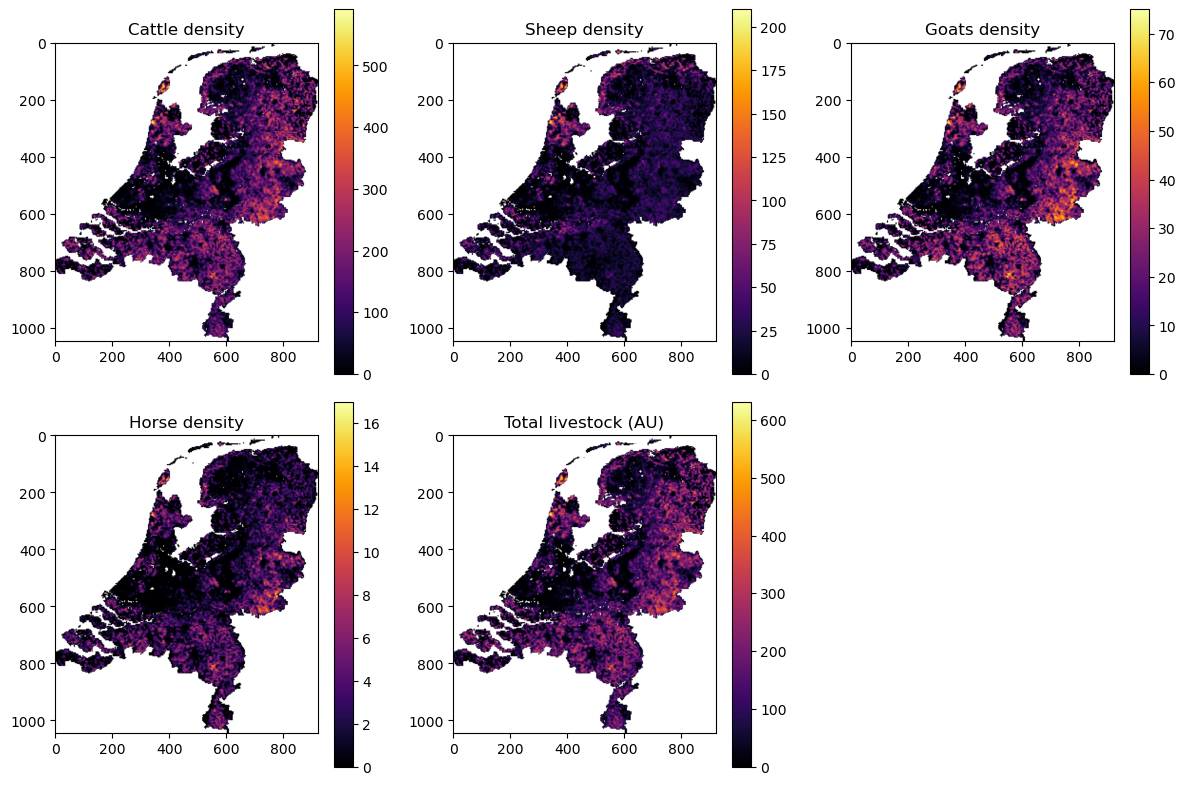

In [40]:
# --- diagnostic plot AU ---
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1); plt.imshow(cattle, cmap="inferno"); plt.title("Cattle density"); plt.colorbar()
plt.subplot(2, 3, 2); plt.imshow(sheep,  cmap="inferno"); plt.title("Sheep density");  plt.colorbar()
plt.subplot(2, 3, 3); plt.imshow(goats,  cmap="inferno", vmin=0, vmax=max(1e-6, np.nanmax(goats))); plt.title("Goats density");  plt.colorbar()
plt.subplot(2, 3, 4); plt.imshow(horse, cmap="inferno", vmin=0, vmax=max(1e-6, np.nanmax(horse))); plt.title("Horse density");  plt.colorbar()
plt.subplot(2, 3, 5); plt.imshow(AU_total, cmap="inferno"); plt.title("Total livestock (AU)"); plt.colorbar()
plt.tight_layout(); plt.show()


#### STEP 5 Relative Stocking Density

In [41]:

# == STEP 5 — RELATIVE STOCKING DENSITY == #
# RSD = AU_observed / AU_carrying

RSD = np.full_like(npp, np.nan, dtype="float32")

valid = (npp > 0) & np.isfinite(CC) & (CC > 0) & (AU_total >= 0)

RSD[valid] = AU_total[valid] / CC[valid]


print("RSD summary:")
print("  Min:", np.nanmin(RSD))
print("  Mean:", np.nanmean(RSD))
print("  Max:", np.nanmax(RSD))


RSD summary:
  Min: 0.0
  Mean: 0.9620603
  Max: 14677.474


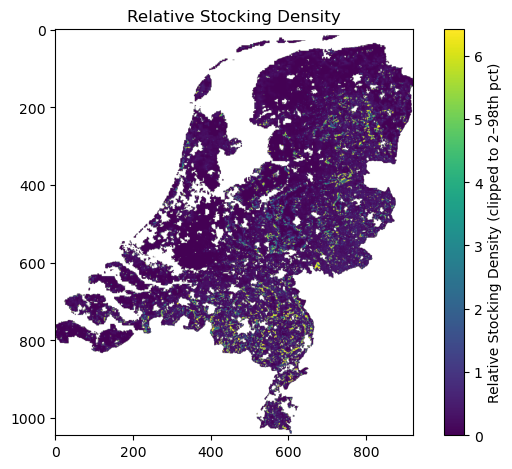

In [48]:
# Plot percentiles
p_lo, p_hi = 2, 98
vmin, vmax = np.nanpercentile(RSD, [p_lo, p_hi])

plt.imshow(RSD, cmap="viridis", vmin=vmin, vmax=vmax)
plt.colorbar(label=f"Relative Stocking Density (clipped to {p_lo}–{p_hi}th pct)")
plt.title("Relative Stocking Density")
plt.tight_layout()
plt.show()

In [49]:
## STEP 6 — Save Output ##

profile_out = profile.copy()
profile_out.update(
    dtype="float32",
    compress="lzw"
)

with rasterio.open(out_path, "w", **profile_out) as dst:
    dst.write(RSD, 1)

print(f"✅ Saved RSD raster: {out_path}")

✅ Saved RSD raster: /home/georg/data/LEON_P5_BII/EO_data_prep/Grazing_intensity/RSD_nld_2018.tif


#### Check RSD
How much average RSD within Pasture areas

In [ ]:
# Inputs
pasture_path = base_path / "EO_data_prep/LC_urban_pasture/lc_urban5_pasture_dnk_2023.tif"

PASTURE_VALUE = 41  # pasture class
TARGET_SHAPE = RSD.shape     # (rows, cols)
TARGET_PROFILE = profile     # from NPP (EPSG:3035)

# Reproject pasture raster to RSD grid #
with rasterio.open(pasture_path) as src:
    pasture_reproj = np.full(TARGET_SHAPE, np.nan, dtype="float32")
    reproject(
        source=rasterio.band(src, 1),
        destination=pasture_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=TARGET_PROFILE["transform"],
        dst_crs=TARGET_PROFILE["crs"],
        src_nodata=src.nodata,
        dst_nodata=np.nan,
        resampling=Resampling.nearest
    )

# Build pasture mask on RSD grid
pasture_mask = pasture_reproj == PASTURE_VALUE

print("Pasture pixels (RSD grid):", np.sum(pasture_mask))
print("Pasture fraction of grid:",
      np.sum(pasture_mask) / pasture_mask.size)

# Apply mask and compute stats
RSD_pasture = np.where(pasture_mask, RSD, np.nan)

print("\nRSD over pasture only:")
print("  Min :", np.nanmin(RSD_pasture))
print("  Mean:", np.nanmean(RSD_pasture))
print("  Max :", np.nanmax(RSD_pasture))


In [ ]:
plt.hist(RSD_pasture[np.isfinite(RSD_pasture)], bins=50, log=True); 
plt.xlabel("RSD"); plt.ylabel("Pixel count"); plt.title("Histogram of pasture RSD"); plt.show()

In [ ]:

print(dict(zip([5,10,25,50,75,90,95,99], np.nanpercentile(RSD_pasture, [5,10,25,50,75,90,95,99]))))


Interpretation (Piipponen et al. 2022)

RSD value Interpretation: < 0.20 Low grazing pressure; 0.20 – 0.65 Sustainable grazing; > 0.65 Overstocked